In [4]:
%load_ext autoreload
%autoreload 2
import numpy as np
import h5py
import json
import matplotlib.pyplot as plt

from tqdm import tqdm
import torch
import torch.nn as nn
from torchvision import transforms
from torch.utils.data import DataLoader
from dl_utils.utils.dataset import viz_dataloader, split_train_valid, hdf5_dataset
from dl_utils.training.build_model import resnet50_, xcit_small
from dl_utils.training.trainer import Trainer, accuracy
from dl_utils.packed_functions import benchmark_task
from dl_utils.utils.utils import list_to_dict, sort_tasks_by_size, find_last_epoch_file, viz_h5_structure

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


(10013, 256, 256, 3)


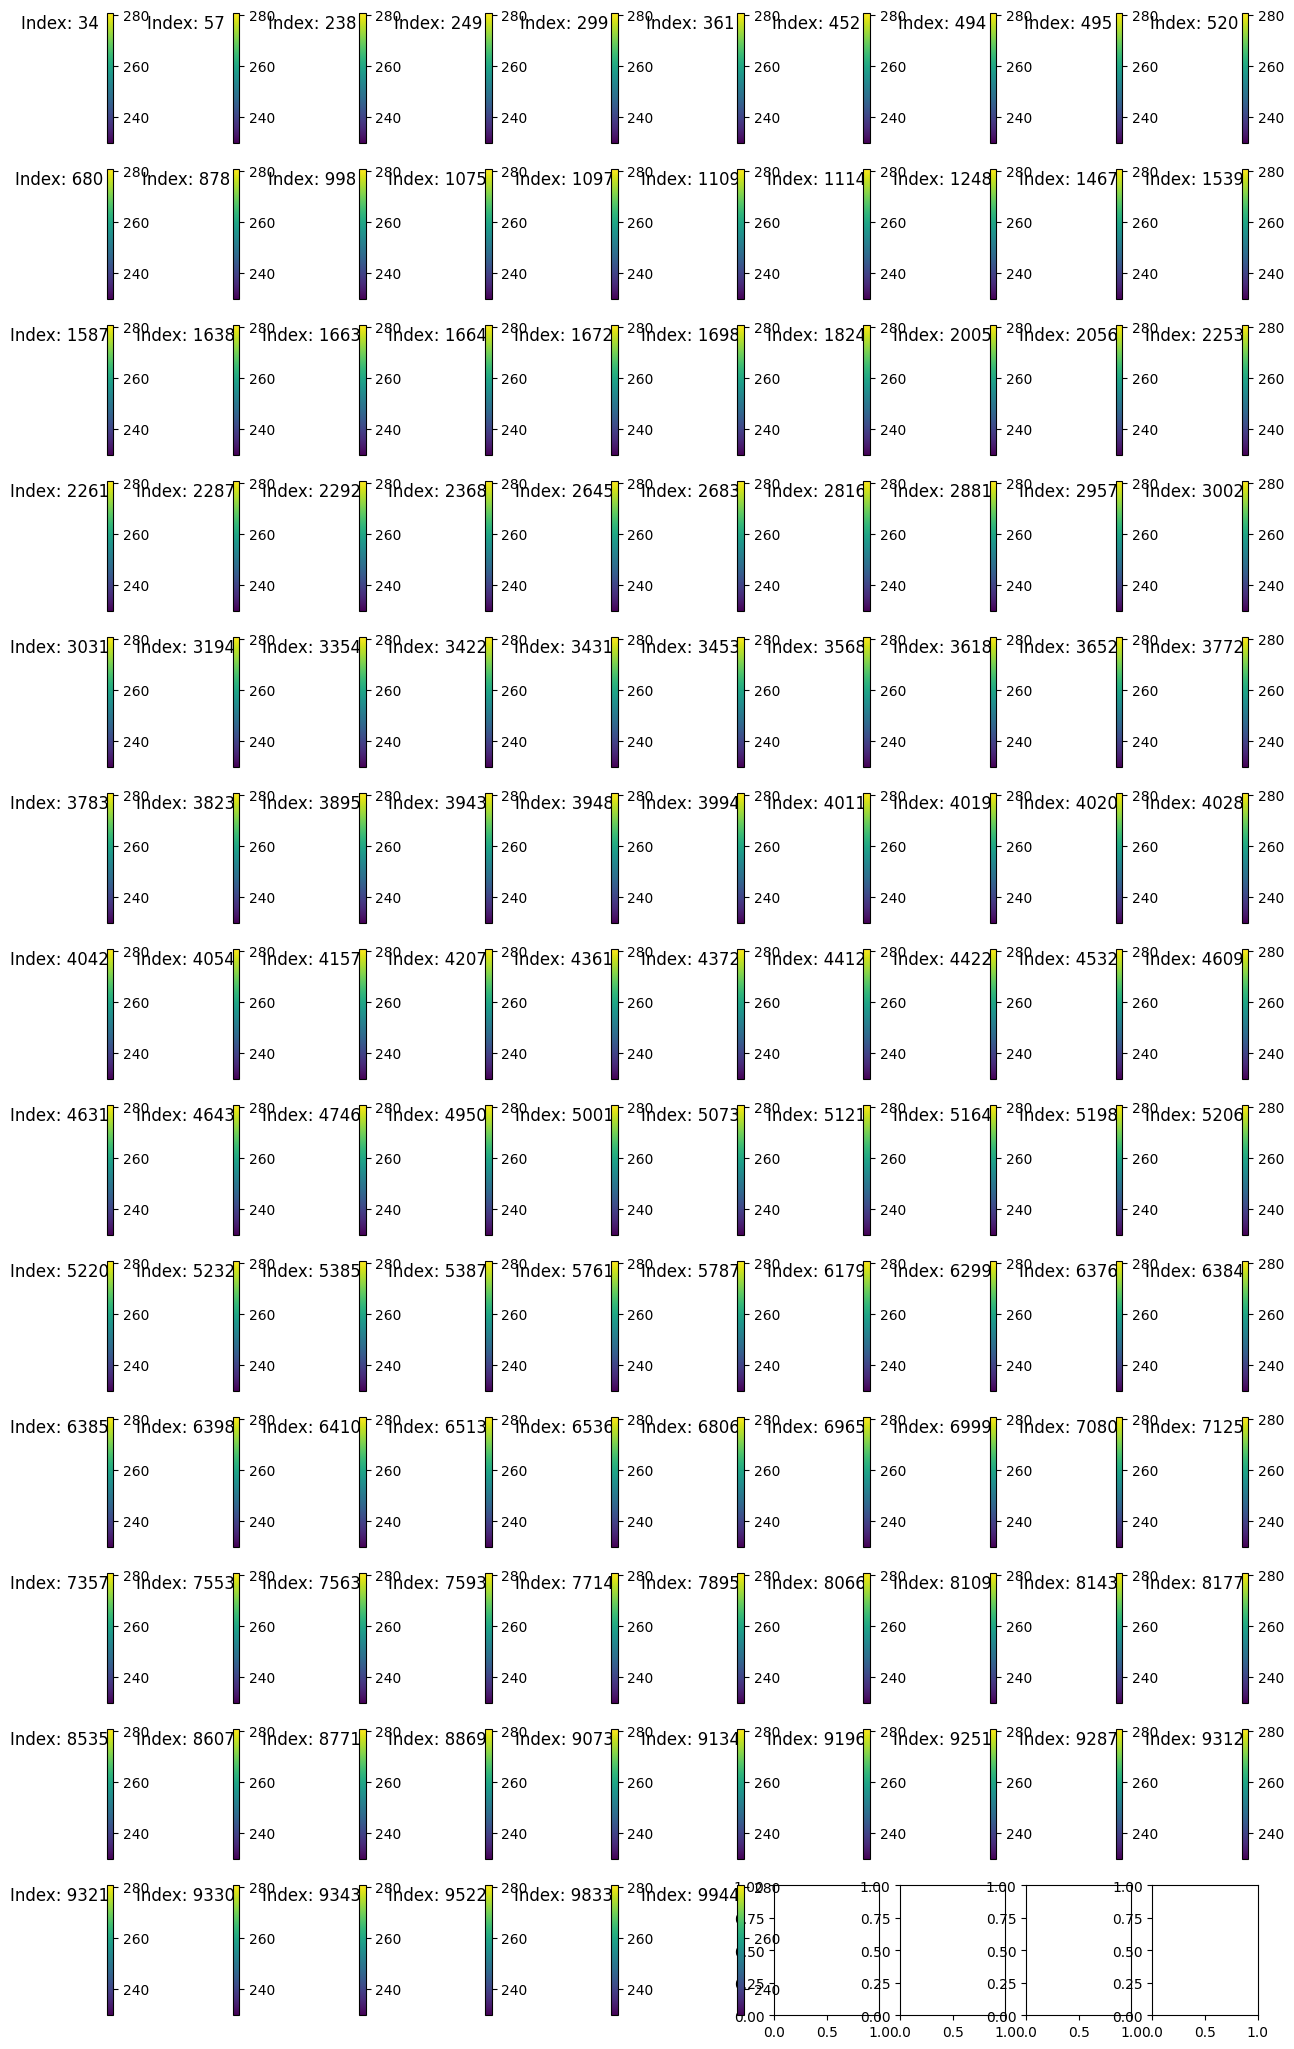

In [21]:
with h5py.File('../../datasets/imagenet_v5_rot_10k_fix_vector_a100_0.h5', 'r') as h5:
    print(h5['imagenet']['data'].shape)
    l = [34, 57, 238, 249, 299, 361, 452, 494, 495, 520, 680, 878, 998, 1075, 1097, 1109, 1114, 1248, 1467, 1539, 1587, 1638, 1663, 1664, 1672, 1698, 1824, 2005, 2056, 2253, 2261, 2287, 2292, 2368, 2645, 2683, 2816, 2881, 2957, 3002, 3031, 3194, 3354, 3422, 3431, 3453, 3568, 3618, 3652, 3772, 3783, 3823, 3895, 3943, 3948, 3994, 4011, 4019, 4020, 4028, 4042, 4054, 4157, 4207, 4361, 4372, 4412, 4422, 4532, 4609, 4631, 4643, 4746, 4950, 5001, 5073, 5121, 5164, 5198, 5206, 5220, 5232, 5385, 5387, 5761, 5787, 6179, 6299, 6376, 6384, 6385, 6398, 6410, 6513, 6536, 6806, 6965, 6999, 7080, 7125, 7357, 7553, 7563, 7593, 7714, 7895, 8066, 8109, 8143, 8177, 8535, 8607, 8771, 8869, 9073, 9134, 9196, 9251, 9287, 9312, 9321, 9330, 9343, 9522, 9833, 9944]

    fig, axes = plt.subplots(len(l)//10+1, 10, figsize=(16, (len(l)//5+1)*1))
    for idx, ax in zip(l, axes.flatten()):
        img = np.array(h5['imagenet']['data'][idx])
        im = ax.imshow(img)
        ax.set_title(f'Index: {idx}')
        plt.colorbar(im, ax=ax)
        ax.axis('off')
    plt.show()

In [19]:
import h5py
import numpy as np
from collections import Counter, defaultdict
import hashlib

def inspect_images(h5_path, dataset_key=('imagenet', 'data'), indices=None, bins=256):
    """Checks whether selected images are byte-identical and compares their pixel distributions."""
    with h5py.File(h5_path, 'r') as h5:
        ds = h5
        for k in dataset_key:
            ds = ds[k]
        if indices is None:
            indices = range(len(ds))
        imgs = {idx: np.array(ds[idx]) for idx in indices}

    def hash_img(img):
        return hashlib.sha256(img.tobytes()).hexdigest()

    hashes = {idx: hash_img(img) for idx, img in imgs.items()}
    all_same = len(set(hashes.values())) == 1
    print(f"All selected images identical: {all_same}")
    if not all_same:
        first = next(iter(hashes.values()))
        diffs = [idx for idx, h in hashes.items() if h != first]
        print(f"First differing index: {diffs[0]}")

    histograms = {
        idx: np.histogram(img, bins=bins, range=(0, 255), density=True)[0]
        for idx, img in imgs.items()
    }

    hist_groups = defaultdict(list)
    for idx, hist in histograms.items():
        hist_groups[tuple(np.round(hist, 6))].append(idx)

    print("\nHistogram groups (identical pixel distributions):")
    for hist_signature, idx_list in hist_groups.items():
        print(idx_list)

    return hashes, histograms

In [20]:
indices = [34, 57, 238, 249, 299, 361, 452, 494, 495, 520, 680, 878, 998, 1075, 1097, 1109, 1114, 1248, 1467, 1539, 1587, 1638, 1663, 1664, 1672, 1698, 1824, 2005, 2056, 2253, 2261, 2287, 2292, 2368, 2645, 2683, 2816, 2881, 2957, 3002, 3031, 3194, 3354, 3422, 3431, 3453, 3568, 3618, 3652, 3772, 3783, 3823, 3895, 3943, 3948, 3994, 4011, 4019, 4020, 4028, 4042, 4054, 4157, 4207, 4361, 4372, 4412, 4422, 4532, 4609, 4631, 4643, 4746, 4950, 5001, 5073, 5121, 5164, 5198, 5206, 5220, 5232, 5385, 5387, 5761, 5787, 6179, 6299, 6376, 6384, 6385, 6398, 6410, 6513, 6536, 6806, 6965, 6999, 7080, 7125, 7357, 7553, 7563, 7593, 7714, 7895, 8066, 8109, 8143, 8177, 8535, 8607, 8771, 8869, 9073, 9134, 9196, 9251, 9287, 9312, 9321, 9330, 9343, 9522, 9833, 9944]
hashes, hists = inspect_images(
    "../../datasets/imagenet_v5_rot_10k_fix_vector_a100_0.h5",
    dataset_key=("imagenet", "data"),
    indices=indices,
    bins=256,
)

All selected images identical: True

Histogram groups (identical pixel distributions):
[34, 57, 238, 249, 299, 361, 452, 494, 495, 520, 680, 878, 998, 1075, 1097, 1109, 1114, 1248, 1467, 1539, 1587, 1638, 1663, 1664, 1672, 1698, 1824, 2005, 2056, 2253, 2261, 2287, 2292, 2368, 2645, 2683, 2816, 2881, 2957, 3002, 3031, 3194, 3354, 3422, 3431, 3453, 3568, 3618, 3652, 3772, 3783, 3823, 3895, 3943, 3948, 3994, 4011, 4019, 4020, 4028, 4042, 4054, 4157, 4207, 4361, 4372, 4412, 4422, 4532, 4609, 4631, 4643, 4746, 4950, 5001, 5073, 5121, 5164, 5198, 5206, 5220, 5232, 5385, 5387, 5761, 5787, 6179, 6299, 6376, 6384, 6385, 6398, 6410, 6513, 6536, 6806, 6965, 6999, 7080, 7125, 7357, 7553, 7563, 7593, 7714, 7895, 8066, 8109, 8143, 8177, 8535, 8607, 8771, 8869, 9073, 9134, 9196, 9251, 9287, 9312, 9321, 9330, 9343, 9522, 9833, 9944]


In [22]:
import h5py
import numpy as np

def all_white_mask(arr, value=255):
    arr = np.asarray(arr)
    return np.all(arr == value)

def check_all_white(h5_path, dataset_key=('imagenet', 'data'), indices=None, value=255):
    with h5py.File(h5_path, 'r') as h5:
        ds = h5
        for key in dataset_key:
            ds = ds[key]
        if indices is None:
            indices = range(len(ds))

        flags = {}
        for idx in indices:
            img = ds[idx]
            flags[idx] = all_white_mask(img, value=value)

    all_white = all(flags.values())
    print(f"All selected images pure white ({value}): {all_white}")
    if not all_white:
        print("Non-white indices:", [idx for idx, is_white in flags.items() if not is_white])
    return flags

In [23]:
flags = check_all_white(
    "../../datasets/imagenet_v5_rot_10k_fix_vector_a100_0.h5",
    dataset_key=("imagenet", "data"),
    indices=indices,
    value=255,
)

All selected images pure white (255): True


### generate embeddings

In [ ]:
'504', '2860', '6983', '7572'
'34', '57', '238', '249', '299'

In [ ]:
with h5py.File('../../datasets/imagenet_v5_rot_10k_fix_vector_a100_0.h5', 'r') as h5:
    h5_group = h5['imagenet']
    data = h5_group['data']
    print(data.shape)
    
    with h5py.File('../../datasets/imagenet_v5_rot_10k_fix_vector_a100_0_xcit_embeddings.h5', 'w') as h5_out:
        h5_out.create_dataset('embeddings', shape=(data.shape[0], 384), dtype='float32')
        for i in tqdm(range(data.shape[0])):
            img = data[i]
            img = torch.tensor(img).unsqueeze(0).permute(0, 3, 1, 2).float() / 255.0
            with torch.no_grad():
                embedding = model(img)
            h5_out['embeddings'][i] = embedding.cpu().numpy()

(10013, 256, 256, 3)


100%|██████████| 10013/10013 [20:50<00:00,  8.01it/s]


In [ ]:
with h5py.File('../../datasets/imagenet_v5_rot_10k_fix_vector_a100_0_xcit_embeddings.h5', 'r') as h5:
    viz_h5_structure(h5)
    
    print(h5['embeddings'][:5])

'Dataset': embeddings; Shape: (10013, 384); dtype: float32
[[ 8.0026867e-04  9.2046097e-04  3.5570911e-03 ... -4.0445660e-04
   1.8727551e-04  1.5299559e-03]
 [ 1.4723408e-03  1.0559600e-03  1.5489649e-04 ...  3.2264463e-04
   2.2407285e-05 -1.5636458e-03]
 [ 1.5780854e-03  1.0829333e-03  1.7200188e-03 ...  4.2441179e-04
   2.0487205e-05 -2.1541815e-03]
 [ 1.1525353e-03  9.7975903e-04  4.7592833e-04 ... -1.0869782e-04
   1.2807883e-04  6.3858570e-05]
 [ 5.0207018e-04  8.5420749e-04  1.9978317e-03 ... -7.6333422e-04
   2.6043880e-04  2.5814015e-03]]
